In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
%cd /content/drive/MyDrive/COMP3710/A3/PatternAnalysis-2025/recognition/FaceBook_solution_47441466
!ls
!pip install -r requirements.txt

/content/drive/MyDrive/COMP3710/A3/PatternAnalysis-2025/recognition
Data  FaceBook_solution_47441466  README.md  requirements.txt


/content/drive/MyDrive/COMP3710/A3/PatternAnalysis-2025/recognition/Facebook_solution_47441466
Test Accuracy: 0.9488


/content/drive/MyDrive/COMP3710/A3/PatternAnalysis-2025/recognition/Facebook_solution_47441466/train.py:140: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


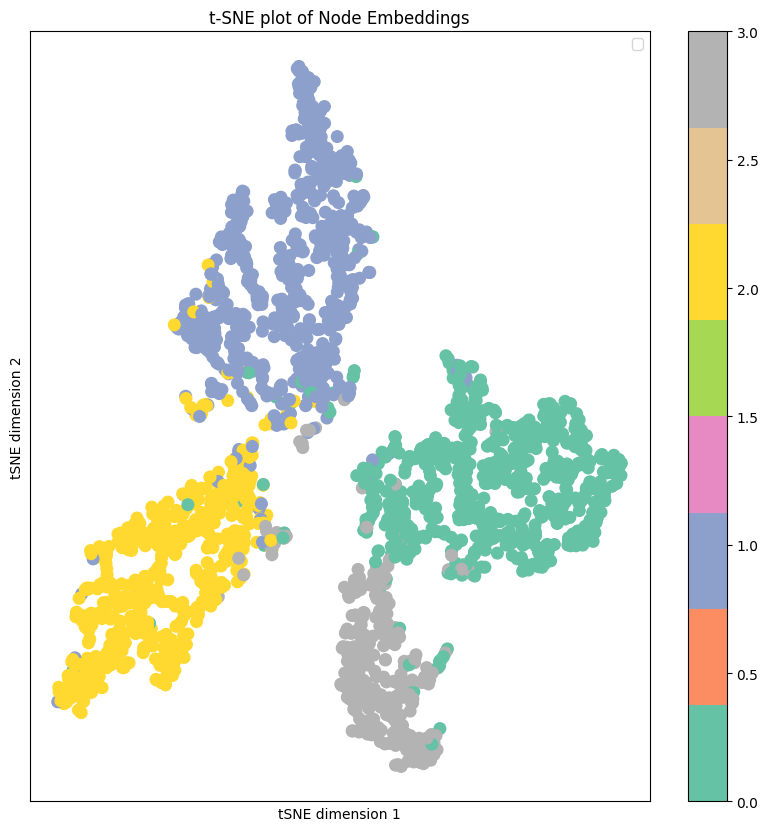

In [2]:
#after training and saving a model, I can load it here and use it for inference.
%cd /content/drive/MyDrive/COMP3710/A3/PatternAnalysis-2025/recognition/Facebook_solution_47441466

import torch
import numpy as np
import random
from train import Trainer
from config import MODEL_PATH, DATA_PATH_PREFIX, SEED, TEST_RATIO, TRAIN_RATIO, VAL_RATIO


# Set seed for reproducibility and device
if SEED is None:
  SEED = random.randint(0,10000)
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### Load data ###
    #model parameters are all autocompleted in trainer init based on the data,
    #test data is also set up in the model
    #instantiate a new model with the weights in the model path weights
    #predict_mode=True ensures that we use the given model
predictor = Trainer(model_path=MODEL_PATH, data_path_prefix=DATA_PATH_PREFIX, predict_mode=True)

#### Inference ###
preds, labels, embeddings = predictor.predict()

### Visualise the t-SNE plot###
predictor.visualise(embeddings, labels)